In [34]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [35]:
# ==========================
# UPLOAD DATASET ZIP
# ==========================

print("Upload archive.zip downloaded from Kaggle")

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully.")

Upload archive.zip downloaded from Kaggle


Saving archive.zip to archive (1).zip
Dataset extracted successfully.


In [36]:
# ==========================
# LOCATE DATASET
# ==========================

dataset_path = None

for root, dirs, files_ in os.walk("/content"):
    if "yes" in dirs and "no" in dirs:
        dataset_path = root
        break

if dataset_path is None:
    raise FileNotFoundError(
        "Could not find folders named 'yes' and 'no'."
    )

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

print("Dataset found at:", dataset_path)
print("Tumour images:", len(os.listdir(yes_path)))
print("No Tumour images:", len(os.listdir(no_path)))

Dataset found at: /content
Tumour images: 155
No Tumour images: 98


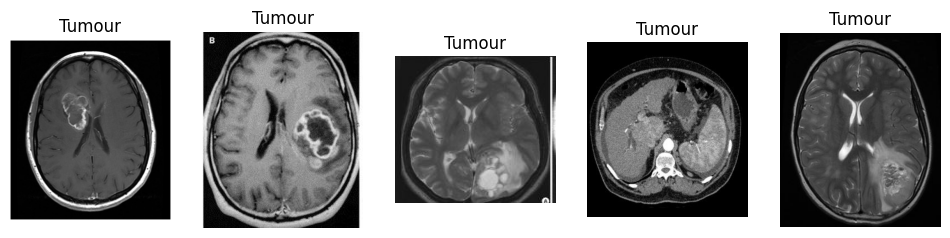

In [37]:
# ==========================
# DISPLAY SAMPLE IMAGES
# ==========================

yes_images = os.listdir(yes_path)

plt.figure(figsize=(12,4))

for i in range(min(5, len(yes_images))):
    img = cv2.imread(os.path.join(yes_path, yes_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Tumour")

plt.show()

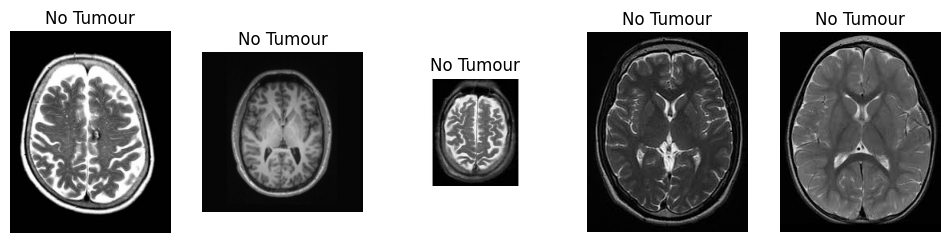

In [38]:
no_images = os.listdir(no_path)

plt.figure(figsize=(12,4))

for i in range(min(5, len(no_images))):
    img = cv2.imread(os.path.join(no_path, no_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("No Tumour")

plt.show()

In [39]:
# ==========================
# LOAD DATASET
# ==========================

X = []
y = []

# Tumour images
for img_name in os.listdir(yes_path):
    path = os.path.join(yes_path, img_name)

    img = cv2.imread(path)

    if img is not None:
        img = cv2.resize(img, (128,128))
        X.append(img)
        y.append(1)

# No tumour images
for img_name in os.listdir(no_path):
    path = os.path.join(no_path, img_name)

    img = cv2.imread(path)

    if img is not None:
        img = cv2.resize(img, (128,128))
        X.append(img)
        y.append(0)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(X.shape)
print(y.shape)

(253, 128, 128, 3)
(253,)


In [40]:
# ==========================
# NORMALIZATION
# ==========================

X = X / 255.0

print("Min:", X.min())
print("Max:", X.max())

Min: 0.0
Max: 1.0


In [41]:
# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(202, 128, 128, 3)
(51, 128, 128, 3)


In [42]:
# ==========================
# CNN MODEL
# ==========================

model = Sequential([

    Input(shape=(128,128,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# ==========================
# DATA AUGMENTATION
# ==========================

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [44]:
# ==========================
# TRAIN MODEL
# ==========================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5743 - loss: 0.6951 - val_accuracy: 0.6078 - val_loss: 0.6032
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6436 - loss: 0.6163 - val_accuracy: 0.8431 - val_loss: 0.5359
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6485 - loss: 0.6004 - val_accuracy: 0.7451 - val_loss: 0.5491
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6832 - loss: 0.5802 - val_accuracy: 0.8235 - val_loss: 0.4992
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7030 - loss: 0.5715 - val_accuracy: 0.7843 - val_loss: 0.4658
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6634 - loss: 0.5999 - val_accuracy: 0.7843 - val_loss: 0.5145
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6782 - loss: 0.5753 - val_accuracy: 0.8039 - val_loss: 0.5234
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7178 - loss: 0.5429 - val_accuracy: 0.8235 - val_loss: 0.4634
Epoch 9/20
7/7 

In [45]:
# ==========================
# EVALUATION
# ==========================

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8235 - loss: 0.4634
Test Loss: 0.4633793830871582
Test Accuracy: 0.8235294222831726


In [46]:
# ==========================
# CLASSIFICATION REPORT
# ==========================

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step
              precision    recall  f1-score   support

           0       0.87      0.65      0.74        20
           1       0.81      0.94      0.87        31

    accuracy                           0.82        51
   macro avg       0.84      0.79      0.80        51
weighted avg       0.83      0.82      0.82        51



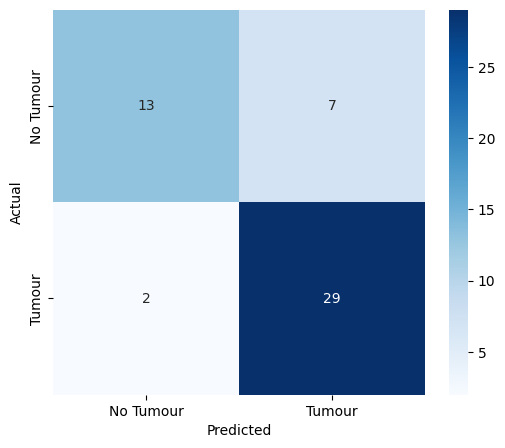

In [47]:
# ==========================
# CONFUSION MATRIX
# ==========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Tumour","Tumour"],
    yticklabels=["No Tumour","Tumour"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
# ==========================
# SAVE MODEL
# ==========================

model.save("brain_tumor_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [49]:
def highlight_tumour_box(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    height, width = gray.shape
    image_area = height * width

    output = img_bgr.copy()

    # Reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Find the brain region
    _, brain_mask = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    brain_mask = cv2.morphologyEx(
        brain_mask,
        cv2.MORPH_CLOSE,
        np.ones((9, 9), np.uint8)
    )

    contours, _ = cv2.findContours(
        brain_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return output

    # Largest contour assumed to be brain
    largest_brain = max(contours, key=cv2.contourArea)

    brain_mask = np.zeros_like(gray)
    cv2.drawContours(brain_mask, [largest_brain], -1, 255, -1)

    # Slightly shrink mask to remove skull
    kernel_size = max(9, int(min(height, width) * 0.04))

    if kernel_size % 2 == 0:
        kernel_size += 1

    inner_brain = cv2.erode(
        brain_mask,
        np.ones((kernel_size, kernel_size), np.uint8),
        iterations=1
    )

    # Contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    brain_pixels = enhanced[inner_brain > 0]

    if len(brain_pixels) == 0:
        return output

    # Bright abnormal regions
    threshold = max(
        np.percentile(brain_pixels, 92),
        np.mean(brain_pixels) + 0.7 * np.std(brain_pixels)
    )

    lesion_mask = np.zeros_like(gray)

    lesion_mask[
        (enhanced >= threshold) &
        (inner_brain > 0)
    ] = 255

    lesion_mask = cv2.morphologyEx(
        lesion_mask,
        cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8)
    )

    lesion_mask = cv2.morphologyEx(
        lesion_mask,
        cv2.MORPH_CLOSE,
        np.ones((7, 7), np.uint8)
    )

    contours, _ = cv2.findContours(
        lesion_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    best_contour = None
    best_score = 0

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < image_area * 0.001:
            continue

        if area > image_area * 0.12:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        if w > width * 0.55 or h > height * 0.55:
            continue

        contour_mask = np.zeros_like(gray)

        cv2.drawContours(
            contour_mask,
            [contour],
            -1,
            255,
            -1
        )

        mean_intensity = cv2.mean(
            enhanced,
            mask=contour_mask
        )[0]

        score = area * mean_intensity

        if score > best_score:
            best_score = score
            best_contour = contour

    if best_contour is not None:
        x, y, w, h = cv2.boundingRect(best_contour)

        padding = 8

        x = max(0, x - padding)
        y = max(0, y - padding)

        w = min(width - x, w + 2 * padding)
        h = min(height - y, h + 2 * padding)

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),   # Red box
            3
        )

    return output

Upload MRI image


Saving Y11.jpg to Y11 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: Tumour Detected


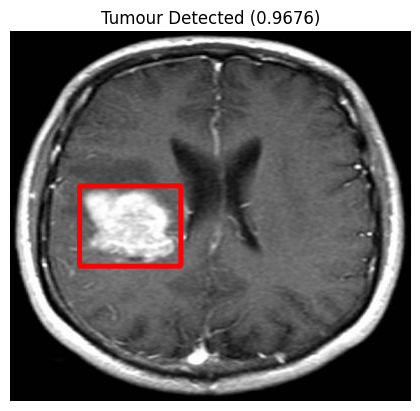

In [55]:
# ==========================
# PREDICT NEW MRI IMAGE
# ==========================

print("Upload MRI image")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

image_bytes = uploaded[filename]

image_array = np.frombuffer(image_bytes, np.uint8)

img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (128,128))
img_resized = img_resized.astype(np.float32) / 255.0
img_resized = np.expand_dims(img_resized, axis=0)

prediction = model.predict(img_resized)

probability = float(prediction[0][0])

plt.imshow(img_display)
plt.axis("off")

if probability > 0.5:
    print("Prediction: Tumour Detected")

    output_img = highlight_tumour_box(img)

    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Tumour Detected ({probability:.4f})")

else:
    print("Prediction: No Tumour Detected")

    plt.imshow(img_display)
    plt.axis("off")
    plt.title(f"No Tumour ({probability:.4f})")

plt.show()